In [3]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('../data/raw/SPY_daily_yahoo_raw.csv', skiprows=[0,1,2], header=None, names=['Date','Adj Close','Close','High','Low','Open','Volume'], index_col=0, parse_dates=True, dtype={'Adj Close': float, 'Close': float, 'High': float, 'Low': float, 'Open': float, 'Volume': int})

# Compute 1-time-index linear increments
df['delta_P'] = df['Adj Close'].diff()

df = df.copy()
t = np.arange(1, len(df) + 1)

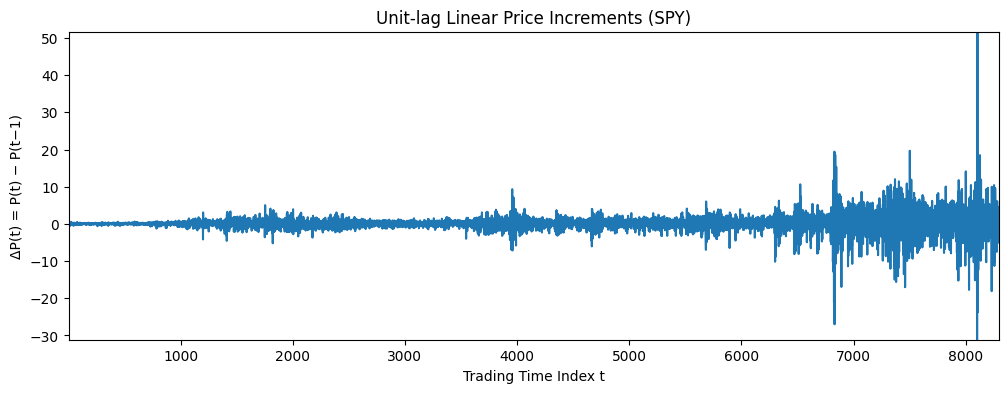

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(t, df['delta_P'])
plt.title('Unit-lag Linear Price Increments (SPY)')
plt.xlabel('Trading Time Index t')
plt.ylabel('ΔP(t) = P(t) − P(t−1)')
plt.xlim(min(t), max(t))
plt.ylim(np.nanmin(df['delta_P']), np.nanmax(df['delta_P']))
plt.show()


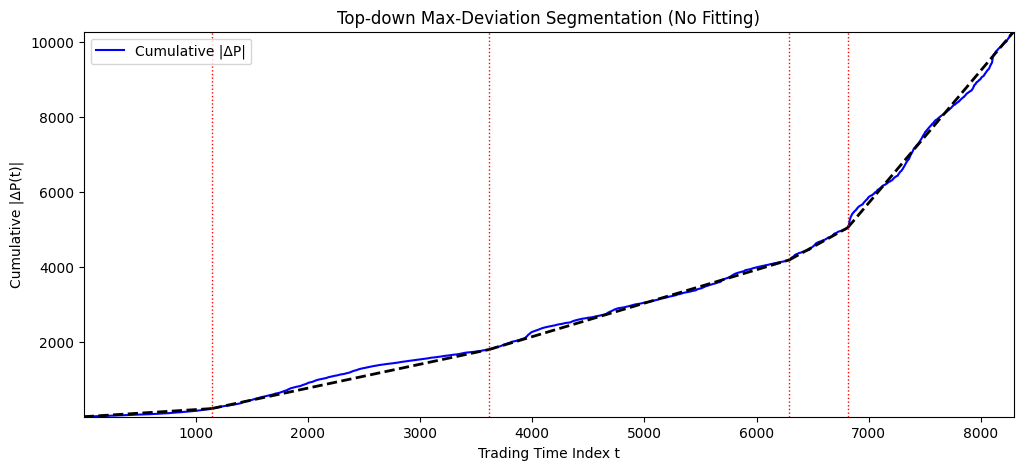

Segment 1: start=1, end=1143, slope=0.1902, N=1143
Segment 2: start=1143, end=3613, slope=0.6373, N=2471
Segment 3: start=3613, end=6293, slope=0.8934, N=2681
Segment 4: start=6293, end=6813, slope=1.6523, N=521
Segment 5: start=6813, end=8292, slope=3.5359, N=1480


In [5]:
# cumulative absolute increments
cum_abs = np.cumsum(np.abs(df['delta_P'].dropna().values))
t = np.arange(1, len(cum_abs)+1)  # start x-axis at 1

max_segments = 5  # keep number of breaks LOW

# initial segment
segments = [(0, len(cum_abs) - 1)]

while len(segments) < max_segments:
    max_err = -1
    best_split = None
    best_segment = None

    for start, end in segments:
        if end - start < 3:
            continue

        # straight line between endpoints (NO fitting)
        line = cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (t[end] - t[start]) * (t[start:end+1] - t[start])
        err = np.abs(cum_abs[start:end+1] - line)

        idx = np.argmax(err)
        if err[idx] > max_err:
            max_err = err[idx]
            best_split = start + idx
            best_segment = (start, end)

    if best_segment is None:
        break

    segments.remove(best_segment)
    segments.append((best_segment[0], best_split))
    segments.append((best_split, best_segment[1]))

segments = sorted(segments, key=lambda x: x[0])

# ---------------- Plot ----------------
plt.figure(figsize=(12,5))
plt.plot(t, cum_abs, color='blue', label='Cumulative |ΔP|')

# plot straight segments
for start, end in segments:
    plt.plot(
        t[start:end+1],
        cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (t[end] - t[start]) * (t[start:end+1] - t[start]),
        color='black',
        linestyle='dashed',
        linewidth=2
    )

# vertical break lines
for _, end in segments[:-1]:
    plt.axvline(t[end], color='red', linestyle='dotted', linewidth=1)  # use t[end] for correct x

plt.xlabel('Trading Time Index t')
plt.ylabel('Cumulative |ΔP(t)|')
plt.xlim(min(t), max(t))
plt.ylim(np.nanmin(cum_abs), np.nanmax(cum_abs))
plt.title('Top-down Max-Deviation Segmentation (No Fitting)')
plt.legend()
plt.show()

# segment summary
for i, (start, end) in enumerate(segments):
    slope = (cum_abs[end] - cum_abs[start]) / (t[end] - t[start])
    print(f"Segment {i+1}: start={t[start]}, end={t[end]}, slope={slope:.4f}, N={end-start+1}")


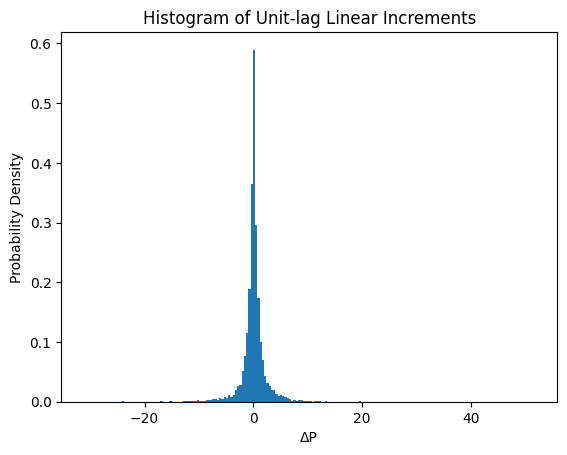

In [6]:
plt.figure()
plt.hist(df['delta_P'].dropna(), bins=200, density=True)
plt.title('Histogram of Unit-lag Linear Increments')
plt.xlabel('ΔP')
plt.ylabel('Probability Density')
plt.show()
# Plot the linear increments

In [ ]:
################################################################################

In [15]:
# --- Step 3: General function to compute conditional PDFs across quantiles and horizons ---
def compute_conditional_pdfs(df, q_values=[0.7, 0.8, 0.9, 0.95], tau_list=[1,2,3,5,10], 
                             num_bins=50, bin_type='linear'):
    """
    Compute empirical conditional PDFs for multiple quantiles and horizons.
    
    Returns a nested dictionary:
    pdfs[direction][q][tau] = (bin_centers, pdf_values, sample_size)
    """
    delta = df['delta_P']
    pdfs = {'+': {}, '-': {}}
    
    for direction in ['+', '-']:
        for q in q_values:
            # --- 1. Identify conditioning event ---
            if direction == '+':
                threshold = delta[delta > 0].quantile(q)
                cond_idx = delta[delta > threshold].index
            else:  # '-'
                threshold = delta[delta < 0].quantile(1 - q)
                cond_idx = delta[delta < threshold].index
            
            pdfs[direction][q] = {}
            
            for tau in tau_list:
                # --- 2. Future increments ---
                future_prices = df['Adj Close'].shift(-tau)
                Y_tau = future_prices[cond_idx] - df['Adj Close'][cond_idx]
                Y_tau = Y_tau.dropna()
                
                if len(Y_tau) == 0:
                    print(f"No samples for direction={direction}, q={q}, tau={tau}")
                    pdfs[direction][q][tau] = (np.array([]), np.array([]), 0)
                    continue
                
                # --- 3. Define bins ---
                min_y, max_y = Y_tau.min(), Y_tau.max()
                if bin_type == 'linear':
                    bins = np.linspace(min_y, max_y, num_bins + 1)
                elif bin_type == 'log':
                    max_abs = max(abs(min_y), abs(max_y))
                    bins_pos = np.logspace(-8, np.log10(max_abs), num_bins//2 + 1)
                    bins = np.concatenate([-bins_pos[::-1], bins_pos])
                else:
                    raise ValueError("bin_type must be 'linear' or 'log'")
                
                # --- 4. Compute empirical PDF ---
                hist, edges = np.histogram(Y_tau, bins=bins, density=True)
                bin_centers = 0.5 * (edges[1:] + edges[:-1])
                
                pdfs[direction][q][tau] = (bin_centers, hist, len(Y_tau))
                
    return pdfs

# --- Example usage ---
q_values = [0.7, 0.8, 0.9, 0.95]
tau_list = [1, 2, 3, 5, 10]
pdfs = compute_conditional_pdfs(df, q_values=q_values, tau_list=tau_list, num_bins=50, bin_type='linear')



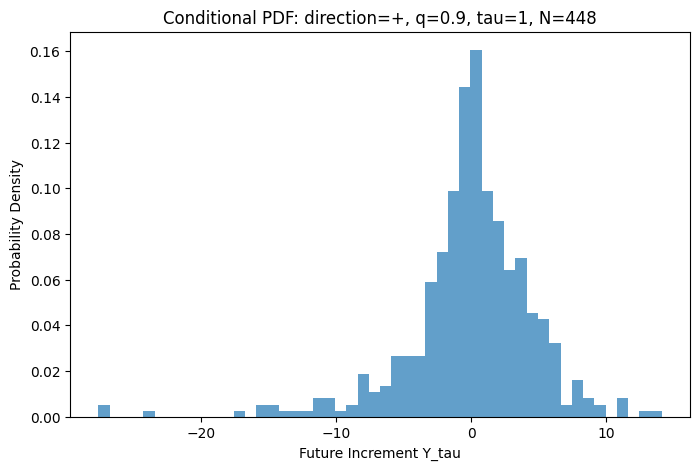

In [16]:
direction = '+'
q = 0.9
tau = 1

bin_centers, pdf_vals, n_samples = pdfs[direction][q][tau]

plt.figure(figsize=(8,5))
plt.bar(bin_centers, pdf_vals, width=bin_centers[1]-bin_centers[0], alpha=0.7)
plt.title(f"Conditional PDF: direction={direction}, q={q}, tau={tau}, N={n_samples}")
plt.xlabel("Future Increment Y_tau")
plt.ylabel("Probability Density")
plt.show()